<a href="https://colab.research.google.com/github/utkarsha-a/ROI-detection/blob/main/04_fuzzy_logic_based_roi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ROI_Endoscopy_Paper

annotations  faster_rcnn_roi.pth  hyper_kvasir_subset  notebooks


In [ ]:
import torch
import torchvision

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASSES = {
    "polyp": 1,
    "lesion": 2,
    "inflammation": 3
}
NUM_CLASSES = len(CLASSES) + 1

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None  # IMPORTANT: no pretrained weights when loading checkpoint
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/ROI_Endoscopy_Paper/faster_rcnn_roi.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
confidence = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence')
size_ratio = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'size_ratio')
location = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'location')

risk = ctrl.Consequent(np.arange(0, 1.01, 0.01), 'risk')

In [ ]:
confidence['low'] = fuzz.trimf(confidence.universe, [0, 0, 0.4])
confidence['medium'] = fuzz.trimf(confidence.universe, [0.3, 0.5, 0.7])
confidence['high'] = fuzz.trimf(confidence.universe, [0.6, 1, 1])

size_ratio['small'] = fuzz.trimf(size_ratio.universe, [0, 0, 0.2])
size_ratio['medium'] = fuzz.trimf(size_ratio.universe, [0.15, 0.35, 0.55])
size_ratio['large'] = fuzz.trimf(size_ratio.universe, [0.4, 1, 1])

location['peripheral'] = fuzz.trimf(location.universe, [0, 0, 0.4])
location['central'] = fuzz.trimf(location.universe, [0.3, 1, 1])

risk['low'] = fuzz.trimf(risk.universe, [0, 0, 0.4])
risk['medium'] = fuzz.trimf(risk.universe, [0.3, 0.5, 0.7])
risk['high'] = fuzz.trimf(risk.universe, [0.6, 1, 1])

Fuzzy rules were designed to incorporate detection confidence, spatial extent, and anatomical relevance

In [ ]:
rules = [
    ctrl.Rule(confidence['high'] & size_ratio['large'], risk['high']),
    ctrl.Rule(confidence['medium'] & size_ratio['medium'], risk['medium']),
    ctrl.Rule(confidence['low'] & size_ratio['small'], risk['low']),
    ctrl.Rule(location['central'] & confidence['medium'], risk['high']),
    ctrl.Rule(location['peripheral'] & confidence['low'], risk['low'])
]

In [ ]:
risk_ctrl = ctrl.ControlSystem(rules)
risk_simulator = ctrl.ControlSystemSimulation(risk_ctrl)

In [ ]:
def compute_size_ratio(box, img_shape):
    xmin, ymin, xmax, ymax = box
    box_area = (xmax - xmin) * (ymax - ymin)
    img_area = img_shape[0] * img_shape[1]
    return box_area / img_area

def compute_location_score(box, img_shape):
    xmin, ymin, xmax, ymax = box
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2

    img_h, img_w = img_shape[:2]
    dist = np.sqrt((cx - img_w/2)**2 + (cy - img_h/2)**2)
    max_dist = np.sqrt((img_w/2)**2 + (img_h/2)**2)

    return 1 - (dist / max_dist)

In [ ]:
def fuzzy_risk_assessment(box, score, img_shape):
    # New simulator every time
    sim = ctrl.ControlSystemSimulation(risk_ctrl)

    size = compute_size_ratio(box, img_shape)
    loc = compute_location_score(box, img_shape)

    # Clamp inputs
    score = float(np.clip(score, 0.0, 1.0))
    size = float(np.clip(size, 0.0, 1.0))
    loc = float(np.clip(loc, 0.0, 1.0))

    sim.input['confidence'] = score
    sim.input['size_ratio'] = size
    sim.input['location'] = loc

    try:
        sim.compute()
        # SAFE access
        return float(sim.output.get('risk', 0.0))
    except Exception:
        # Fallback: no rule fired
        return 0.0

In [ ]:
XML_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml"

In [ ]:
IMG_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images"

In [ ]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

img_name = os.listdir(IMG_DIR)[0]  # take any image
img_path = os.path.join(IMG_DIR, img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_tensor = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

In [ ]:
model.eval()

with torch.no_grad():
    preds = model([img_tensor.to(DEVICE)])[0]

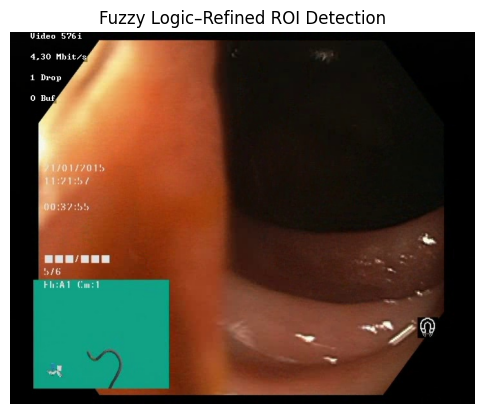

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img)

for box, label, score in zip(
    preds["boxes"],
    preds["labels"],
    preds["scores"]
):
    if score > 0.5:
        box = box.int().tolist()
        risk_score = fuzzy_risk_assessment(box, score.item(), img.shape)

        color = 'green' if risk_score < 0.4 else 'orange' if risk_score < 0.7 else 'red'
        xmin, ymin, xmax, ymax = box

        plt.gca().add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
        )
        plt.text(xmin, ymin-5, f"Risk:{risk_score:.2f}", color=color)

plt.axis("off")
plt.title("Fuzzy Logic–Refined ROI Detection")
plt.show()

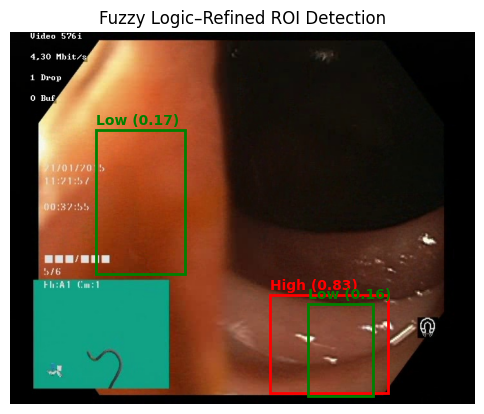

In [ ]:
CONF_THRESH = 0.2  # MUST match RCNN visualization

plt.figure(figsize=(6,6))
plt.imshow(img)

any_box = False

for box, label, score in zip(
    preds["boxes"],
    preds["labels"],
    preds["scores"]
):
    score = score.item()
    if score < CONF_THRESH:
        continue

    any_box = True
    box = box.int().tolist()
    xmin, ymin, xmax, ymax = box

    # Fuzzy risk
    risk_score = fuzzy_risk_assessment(box, score, img.shape)

    # Color mapping
    if risk_score < 0.4:
        color = "green"
        risk_txt = "Low"
    elif risk_score < 0.7:
        color = "orange"
        risk_txt = "Medium"
    else:
        color = "red"
        risk_txt = "High"

    plt.gca().add_patch(
        plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor=color,
            linewidth=2
        )
    )

    plt.text(
        xmin,
        ymin - 8,
        f"{risk_txt} ({risk_score:.2f})",
        color=color,
        fontsize=10,
        weight="bold"
    )

if not any_box:
    print("⚠️ No detections passed threshold for fuzzy processing")

plt.axis("off")
plt.title("Fuzzy Logic–Refined ROI Detection")
plt.show()

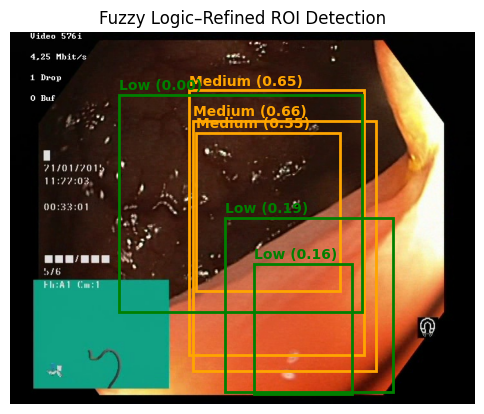

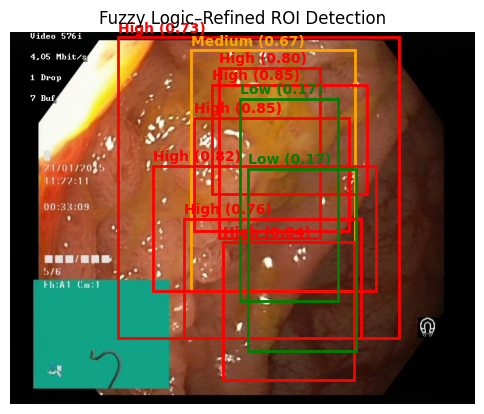

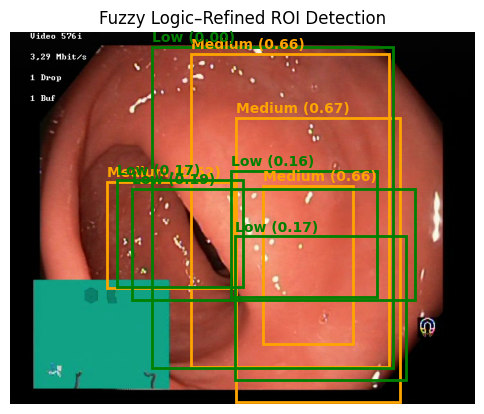

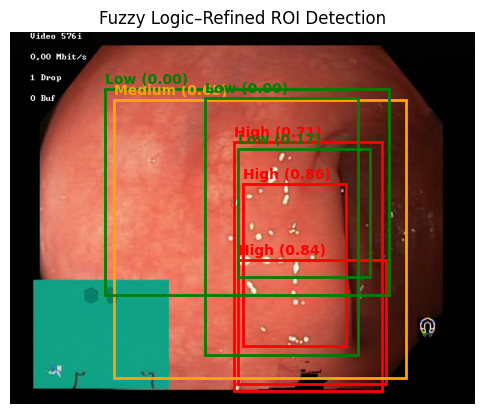

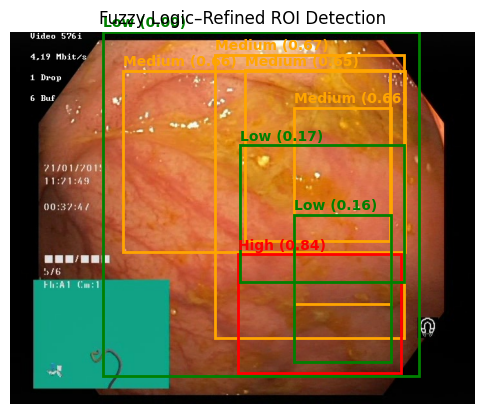

In [ ]:
CONF_THRESH = 0.2
MAX_IMAGES = 5  # change to 10 if you want

xml_files = os.listdir(XML_DIR)

for idx, xml_file in enumerate(xml_files[:MAX_IMAGES]):
    img_name = xml_file.replace(".xml", ".jpg")
    img_path = os.path.join(IMG_DIR, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

    model.eval()
    with torch.no_grad():
        preds = model([img_tensor.to(DEVICE)])[0]

    plt.figure(figsize=(6,6))
    plt.imshow(img)

    any_box = False

    for box, label, score in zip(
        preds["boxes"],
        preds["labels"],
        preds["scores"]
    ):
        score = score.item()
        if score < CONF_THRESH:
            continue

        any_box = True
        box = box.int().tolist()
        xmin, ymin, xmax, ymax = box

        risk_score = fuzzy_risk_assessment(box, score, img.shape)

        if risk_score < 0.4:
            color, risk_txt = "green", "Low"
        elif risk_score < 0.7:
            color, risk_txt = "orange", "Medium"
        else:
            color, risk_txt = "red", "High"

        plt.gca().add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax-xmin,
                ymax-ymin,
                fill=False,
                edgecolor=color,
                linewidth=2
            )
        )
        plt.text(
            xmin, ymin-8,
            f"{risk_txt} ({risk_score:.2f})",
            color=color,
            fontsize=10,
            weight="bold"
        )

    if not any_box:
        plt.title("No ROI detected")
    else:
        plt.title("Fuzzy Logic–Refined ROI Detection")

    plt.axis("off")
    plt.show()

In [ ]:
print("RCNN raw scores:", preds["scores"][:5])

RCNN raw scores: tensor([0.6763, 0.5303, 0.4057, 0.3603, 0.3595])


In [ ]:
import pandas as pd
import os
import cv2
import torch

IMG_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/images"
XML_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations/xml"

OUTPUT_CSV = "/content/drive/MyDrive/ROI_Endoscopy_Paper/fuzzy_results.csv"

CONF_THRESH = 0.2

In [ ]:
records = []

model.eval()

xml_files = os.listdir(XML_DIR)

for xml_file in xml_files:
    img_name = xml_file.replace(".xml", ".jpg")
    img_path = os.path.join(IMG_DIR, img_name)

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

    with torch.no_grad():
        preds = model([img_tensor.to(DEVICE)])[0]

    for box, label, score in zip(
        preds["boxes"],
        preds["labels"],
        preds["scores"]
    ):
        score = score.item()
        if score < CONF_THRESH:
            continue

        box = box.int().tolist()

        # Fuzzy risk
        risk_score = fuzzy_risk_assessment(box, score, img.shape)

        class_name = [k for k, v in CLASSES.items() if v == label.item()][0]

        records.append({
            "image": img_name,
            "class": class_name,
            "confidence": score,
            "risk_score": risk_score
        })

In [ ]:
df = pd.DataFrame(records)
df.to_csv(OUTPUT_CSV, index=False)

print("✅ Fuzzy results saved to:", OUTPUT_CSV)
print(df.head())

✅ Fuzzy results saved to: /content/drive/MyDrive/ROI_Endoscopy_Paper/fuzzy_results.csv
                                               image         class  \
0  1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...         polyp   
1  1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...         polyp   
2  1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...  inflammation   
3  1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...         polyp   
4  1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi_frame...         polyp   

   confidence  risk_score  
0    0.360744    0.664648  
1    0.340797    0.548274  
2    0.319281    0.654798  
3    0.244157    0.185062  
4    0.241956    0.163731  
